In [1]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


# Оценка стоимости земли проекта

In [2]:
scenario_blocks = pd.read_pickle('../data/prostor/scenario_blocks.pickle')
scenario_blocks

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN
...,...,...,...,...,...,...,...,...,...,...
65,"POLYGON ((390950.379 6643779.96, 390941.389 66...",0.000000,1.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,1.000000
66,"POLYGON ((391069.678 6644283.933, 391072.529 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,1.00000,LandUse.AGRICULTURE,1.000000
67,"POLYGON ((388222.552 6643218.262, 388215.418 6...",0.000000,0.000000,0.0,0.0,0.910136,0.0,0.00000,LandUse.TRANSPORT,0.910136
68,"POLYGON ((388314.421 6645193.77, 388311.871 66...",0.000000,1.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,1.000000


In [3]:
blocks = pd.read_pickle('../data/prostor/prepared_blocks.pickle')
blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,AGRICULTURE,0.918180,6260.321243,...,0.0,202399.732193,0.062008,0.030930,0.000000,2.004756,low-rise non-residential,127.337432,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,BUSINESS,0.938081,18143.767788,...,0.0,201529.493481,0.202340,0.090030,0.000000,2.247469,low-rise non-residential,125.993903,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,TRANSPORT,0.891381,15011.641911,...,0.0,164663.859830,0.151737,0.091165,0.000000,1.664419,low-rise non-residential,123.419051,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,RESIDENTIAL,0.934862,22467.055572,...,1467.0,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316006,...,0.0,16.489152,0.079224,0.019164,0.000000,4.133916,mid-rise non-residential,122.658674,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


In [4]:
# Цель: не трогать blocks. Лаги считаем во временном X. В blocks добавляем только 2 колонки.

from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('../data/test/catboost_model_2.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=blocks,
)
blocks_pred = estimator.predict()



In [5]:
# blocks_pred.to_pickle('../data/test/blocks_with_price.pickle')

# Визуализация стоимости земли

Суммарная стоимость:
 • Сценические кварталы: 5 933 522 459 ₽
 • Контекст: 131 295 452 007 ₽
 • Все кварталы: 137 228 974 466 ₽


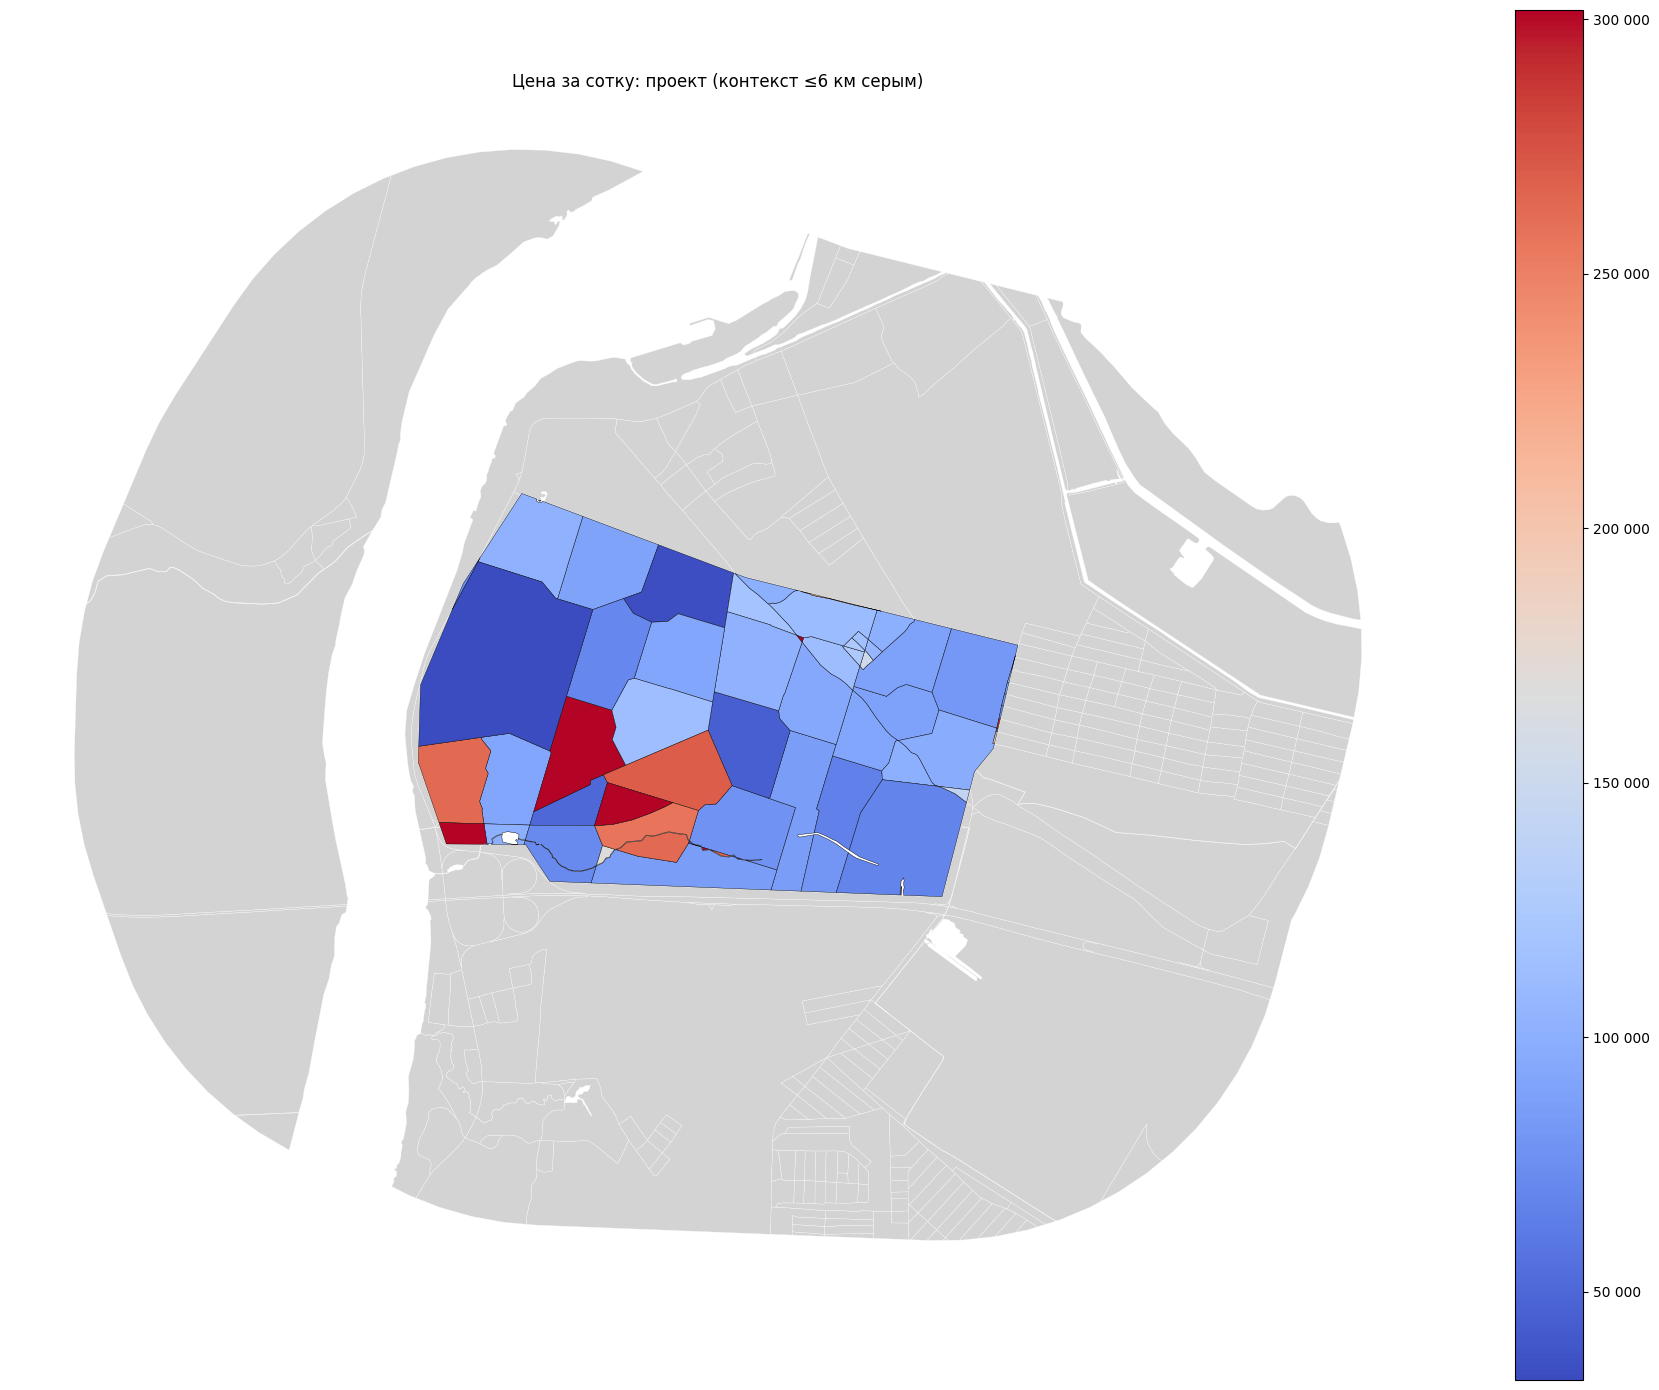

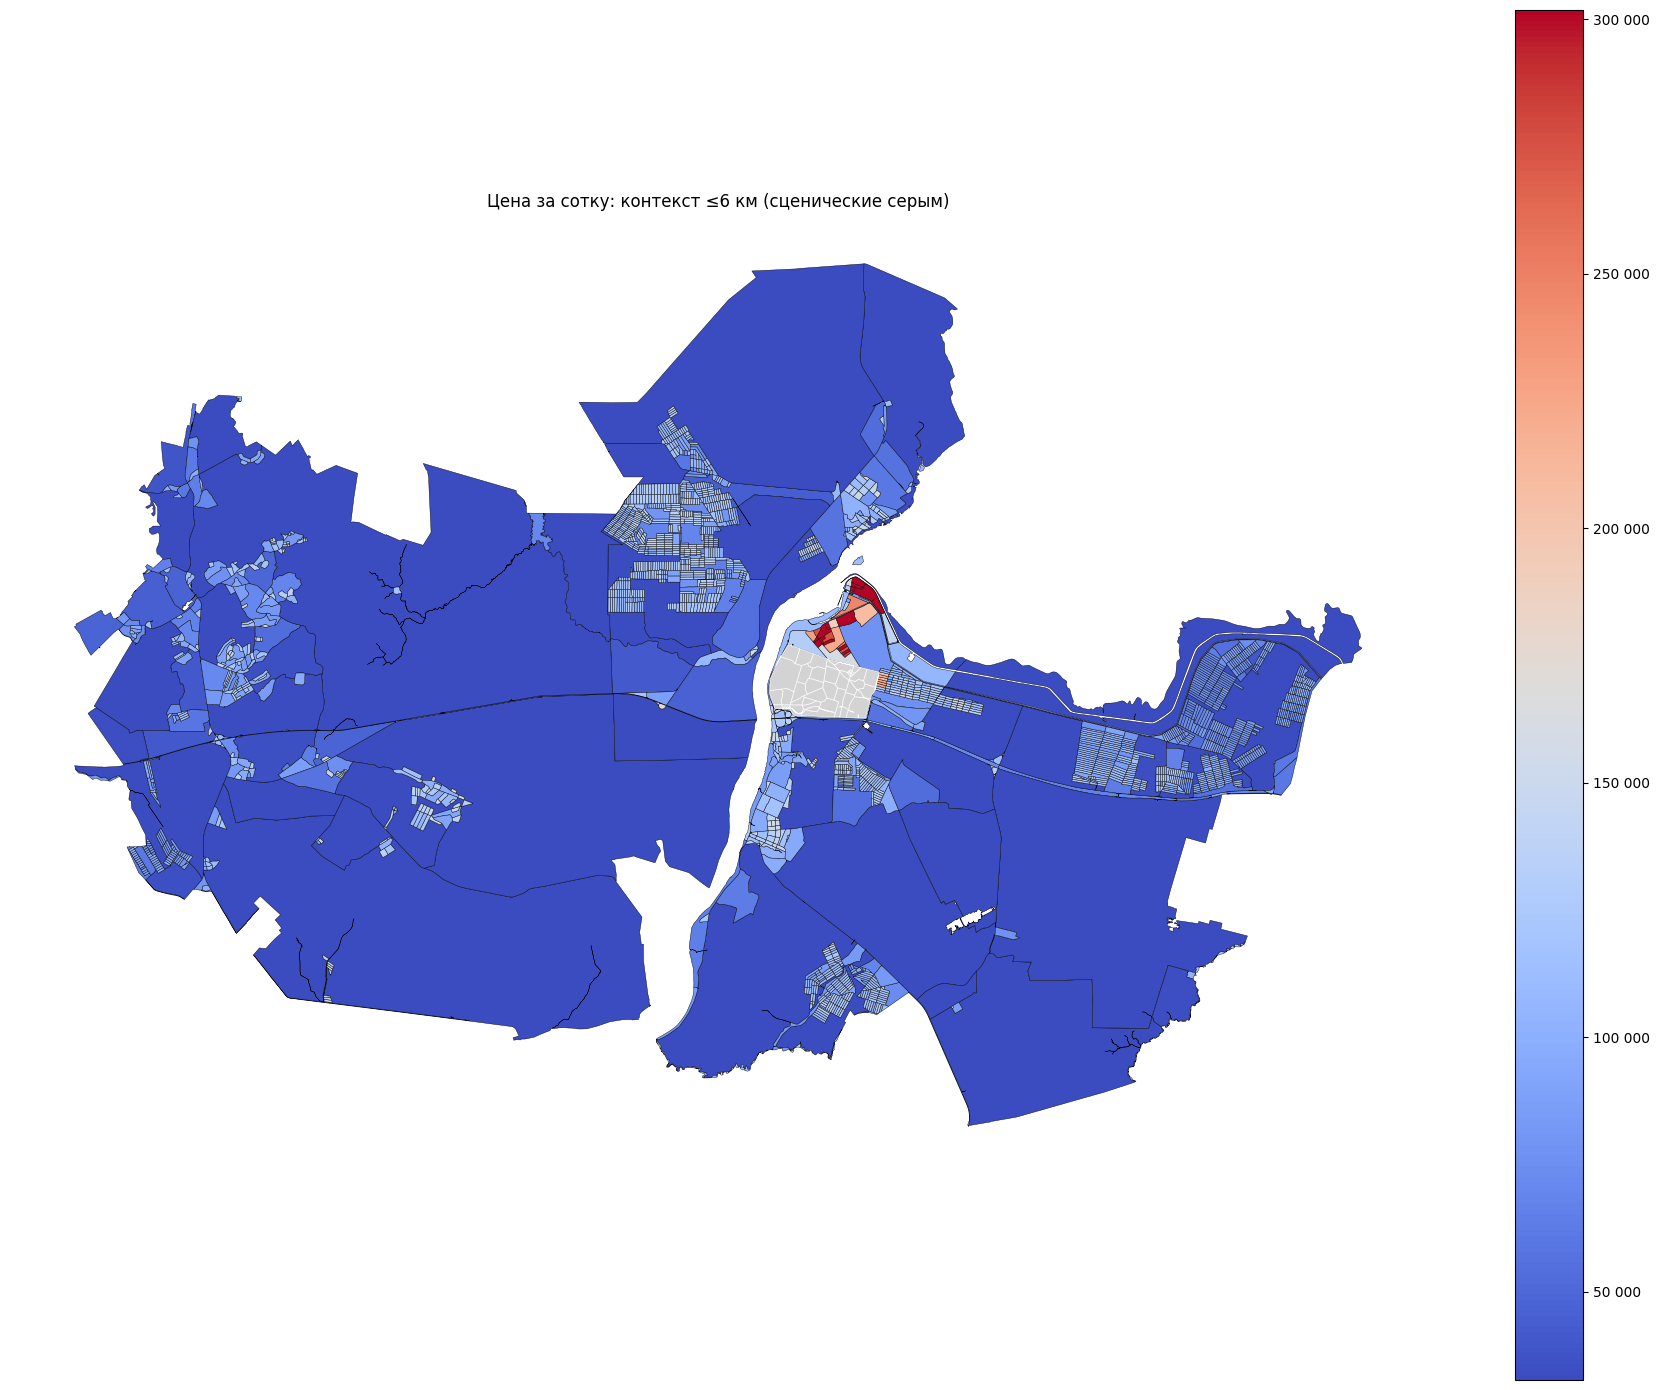

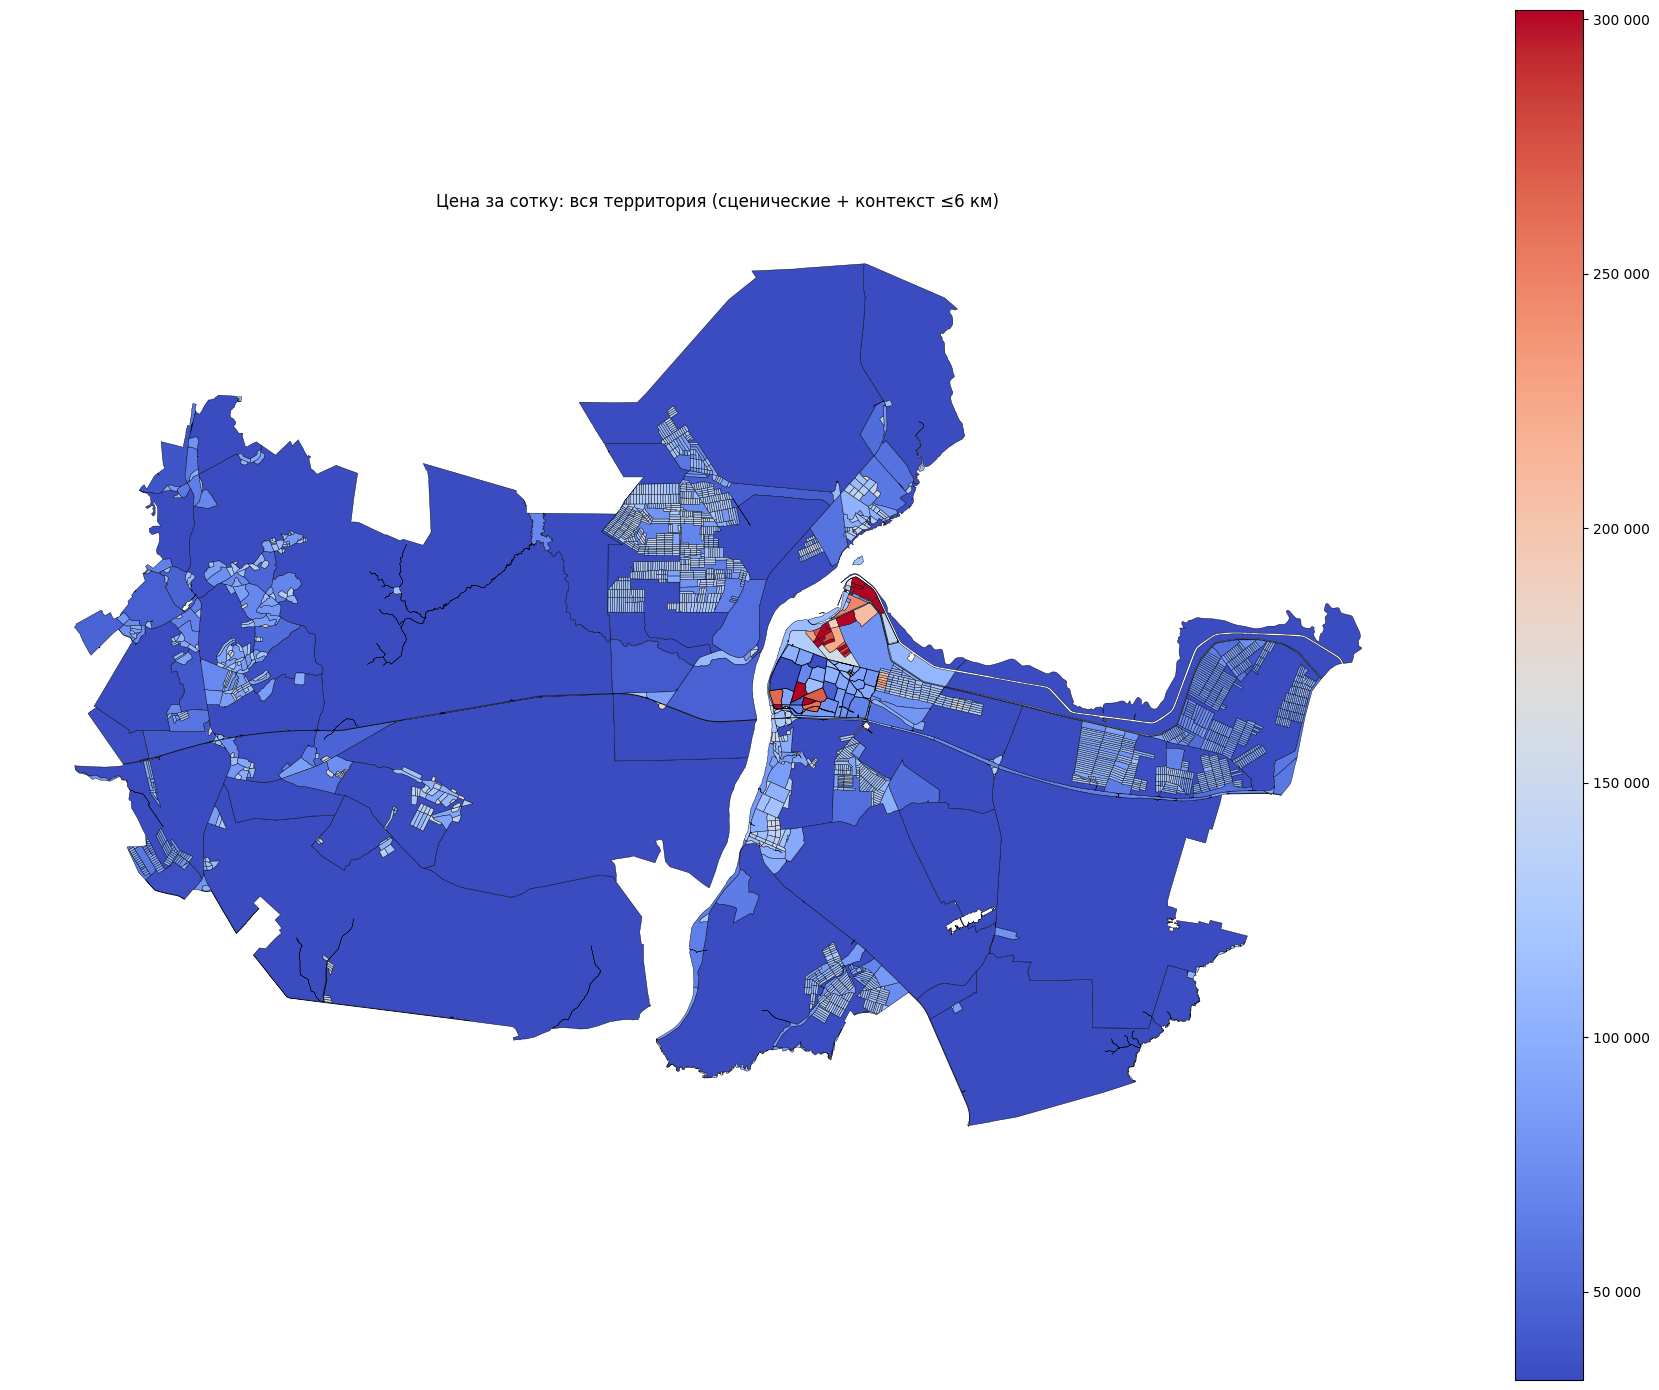

In [6]:
from urbanomy.methods.land_value_modeling import plot_land_price_maps

visualization_output = plot_land_price_maps(
    blocks_pred=blocks_pred,
    scenario_blocks=scenario_blocks,
    buffer_radius_m=2000,
)



# Сценарное изменение ТЭП участков

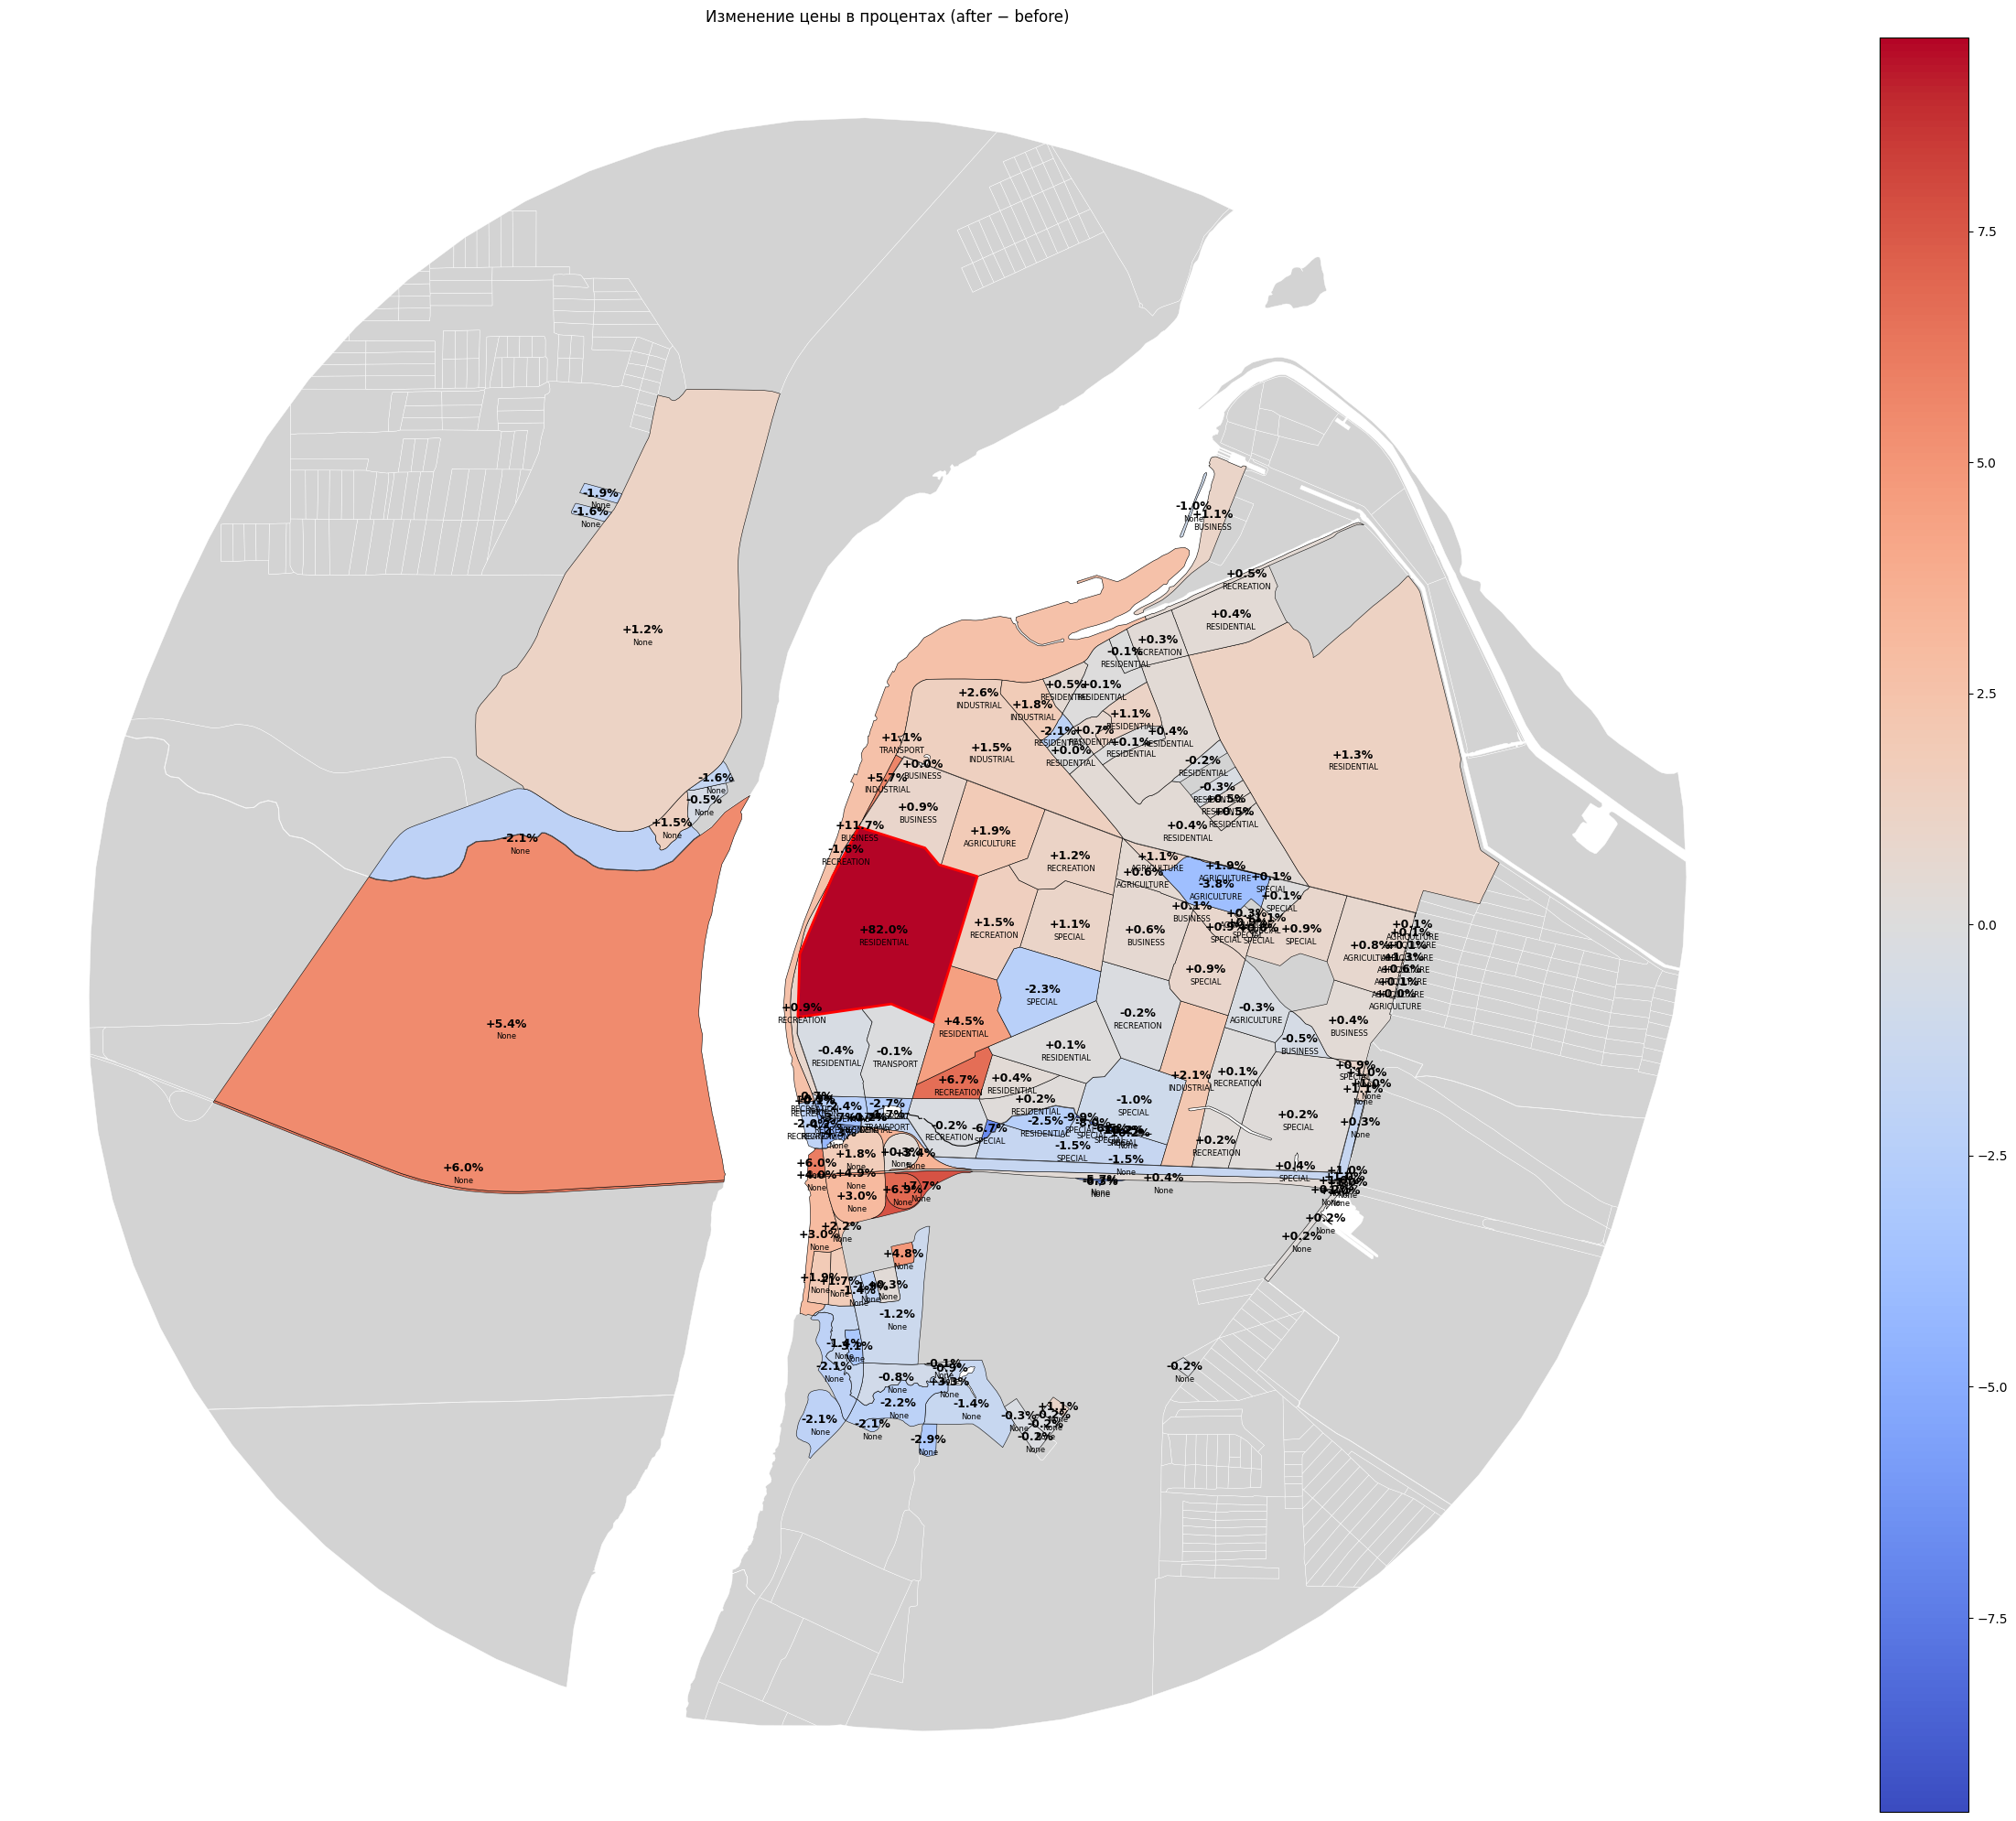


Статистика по кварталам в пределах буфера:
index | до (₽) → после (₽) | Δ₽ | Δ%
1031 | 675 533 009 ₽ → 675 533 009 ₽ | +0 ₽ | +0.0%
1047 | 26 796 971 ₽ → 26 796 971 ₽ | +0 ₽ | +0.0%
1038 | 28 696 804 ₽ → 28 696 804 ₽ | +0 ₽ | +0.0%
1045 | 16 721 270 ₽ → 16 721 270 ₽ | +0 ₽ | +0.0%
1039 | 27 339 693 ₽ → 27 339 693 ₽ | +0 ₽ | +0.0%
1046 | 15 418 062 ₽ → 15 418 062 ₽ | +0 ₽ | +0.0%
1033 | 22 845 832 ₽ → 22 845 832 ₽ | +0 ₽ | +0.0%
1583 | 16 519 740 ₽ → 16 519 740 ₽ | +0 ₽ | +0.0%
1540 | 17 508 202 ₽ → 17 508 202 ₽ | +0 ₽ | +0.0%
1041 | 9 493 984 ₽ → 9 493 984 ₽ | +0 ₽ | +0.0%
1452 | 16 287 662 ₽ → 16 287 662 ₽ | +0 ₽ | +0.0%
120 | 16 146 860 ₽ → 16 146 860 ₽ | +0 ₽ | +0.0%
123 | 22 799 691 ₽ → 22 799 691 ₽ | +0 ₽ | +0.0%
1032 | 17 673 133 ₽ → 17 673 133 ₽ | +0 ₽ | +0.0%
1054 | 17 782 535 ₽ → 17 782 535 ₽ | +0 ₽ | +0.0%
1044 | 8 473 602 ₽ → 8 473 602 ₽ | +0 ₽ | +0.0%
1043 | 6 022 663 ₽ → 6 022 663 ₽ | +0 ₽ | +0.0%
1582 | 8 899 232 ₽ → 8 899 232 ₽ | +0 ₽ | +0.0%
1539 | 8 983 765 ₽ → 8 983 

In [7]:
# ------------ Сценарное изменение ТЭП ------------
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks
changes = {
    'land_use': 'RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
)

